In [1]:
%env JAX_PLATFORM_NAME=cuda
from warnings import simplefilter

import numpy as np


simplefilter(action="ignore", category=FutureWarning)

from test.helpers import (
    SDE,
    simple_batch_sde_solve,
)

import diffrax
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
from diffrax import (
    JumpStepWrapper,
    SaveAt,
    SpaceTimeLevyArea,
)
from weak_sde import get_weak_sde, weak_error


jax.config.update("jax_enable_x64", True)


def draw_order(results_dict):
    fig, ax = plt.subplots()
    fig.set_dpi(100)

    orders = "Orders:\n"
    scats = []
    for i, (name, result) in enumerate(results_dict.items()):
        steps, errs, slice = result
        steps = steps[slice]
        errs = errs[slice]
        trend = np.polyfit(-np.log(steps), np.log(errs), 1)
        order, _ = trend
        # plot the trend line
        # trend_f = np.poly1d(trend)
        # ax.plot(steps, np.exp(trend_f(-np.log(steps))), linewidth=1.0)

        # plot the points
        scat = ax.scatter(
            steps,
            errs,
            label=f"{name}: {order:.2f}",
        )
        scats.append(scat)

        orders += f"{name}: {order:.2f}\n"
    ax.set_yscale("log")
    ax.set_xscale("log")
    ax.set_ylabel("RMS error")
    ax.set_xlabel("Average number of vector field evaluations")
    ax.legend(fancybox=True, fontsize="large")
    plt.show()


t0 = 0.0
t1 = 4.0
saveat = SaveAt(t1=True)
constant_controller = diffrax.ConstantStepSize()
# sde: SDE = get_mlp_sde(t0, t1, jnp.float64, jr.key(0), 5, y_dim=4)
sde: SDE = get_weak_sde(t0, t1, jnp.float64)

num_samples = 100000
keys = jr.split(jr.key(0), num_samples)
sde_name = "weak"

results = {}

env: JAX_PLATFORM_NAME=cuda


In [2]:
ref_filename = f"data/ref_sol_{sde_name}_{num_samples//1000}k.npy"

# from diffrax import Euler, BrownianIncrement
# ref_sol = simple_batch_sde_solve(
#     keys,
#     sde,
#     Euler(),
#     BrownianIncrement,
#     2**-12,
#     constant_controller,
#     0,
#     saveat,
#     use_progress_meter=True,
#     use_vbt=False,
# )
# ref_sols = ref_sol.ys
# jnp.save(ref_filename, ref_sols)

# ref_sols = jnp.load(ref_filename)
# # ref_funs = compute_test_functions(ref_sols)
# ref_errs = weak_error(ref_sols, t0, t1)
# print(ref_errs)

In [3]:
def evaluate_solve(solver, dt, controller):
    sols = simple_batch_sde_solve(
        keys,
        sde,
        solver,
        SpaceTimeLevyArea,
        dt,
        controller,
        2**-10,
        saveat,
        use_progress_meter=True,
        use_vbt=True,
    )
    steps = sols.stats["num_accepted_steps"]
    # errors = comp_fun_dist(sols, ref_funs)
    errors = weak_error(sols.ys, t0, t1)
    return errors, jnp.mean(steps)


def run_const(solver, name, dts=None, steps_mult=1):
    if dts is None:
        dts = [0.5**i for i in range(-2, 8)]
    errors = []
    steps = []
    for dt in dts:
        print(f"dt = {dt}")
        errors_, steps_ = evaluate_solve(solver, dt, constant_controller)
        errors.append(errors_)
        steps.append(steps_)
    errors = jnp.array(errors)
    steps = steps_mult * jnp.array(steps)
    with open(f"data/errors_{sde_name}_sde_{name}_const.npy", "wb") as f:
        jnp.save(f, errors)
        jnp.save(f, steps)
    return errors, steps

In [4]:
from weak_srk.w2ito_foster import W2ItoFoster


# run_const(
#     W2ItoFoster(jr.key(7), error_mode=0), "w2fos", dts=[0.5**i for i in range(-2, 7)], steps_mult=3
# )

with open(f"data/errors_{sde_name}_sde_w2fos_const.npy", "rb") as f:
    errors_w2fos_const = jnp.load(f)
    steps_w2fos_const = jnp.load(f)

results.update(
    {
        "W2Foster constant": (
            steps_w2fos_const,
            errors_w2fos_const,
            slice(None, None),
        )
    }
)

dt = 4.0


100.00%|██████████| [00:00<00:00, 4972.50%/s]


dt = 2.0


100.00%|██████████| [00:00<00:00, 4571.05%/s]


dt = 1.0


...

100.00%|██████████| [00:00<00:00, 193.67%/s]


dt = 0.03125


100.00%|██████████| [00:00<00:00, 101.05%/s]


dt = 0.015625


100.00%|██████████| [00:01<00:00, 52.21%/s]


In [5]:
# Foster adaptive
def run_fos_adaptive(error_mode, recompute=False):
    if recompute:
        atols = [0.25**i for i in range(-1, 6)]
        errors_w2fos_adaptive = []
        steps_w2fos_adaptive = []

        for atol in atols:
            solver = W2ItoFoster(jr.key(7), error_mode=error_mode)
            pid = diffrax.PIDController(
                atol=atol,
                rtol=0.0,
                dtmin=2**-10,
                dtmax=4.0,
                pcoeff=0.2,
                icoeff=0.6,
                error_order=1.0,
            )
            controller = JumpStepWrapper(pid, rejected_step_buffer_len=100)
            print(f"atol = {atol}")
            errors_, steps_ = evaluate_solve(solver, 4.0, controller)
            errors_w2fos_adaptive.append(errors_)
            steps_w2fos_adaptive.append(steps_)

        errors_w2fos_adaptive = jnp.array(errors_w2fos_adaptive)
        steps_w2fos_adaptive = jnp.array(steps_w2fos_adaptive)
        with open(f"data/errors_{sde_name}_sde_w2fos_adap{error_mode}.npy", "wb") as f:
            jnp.save(f, errors_w2fos_adaptive)
            jnp.save(f, steps_w2fos_adaptive)
    else:
        with open(f"data/errors_{sde_name}_sde_w2fos_adap{error_mode}.npy", "rb") as f:
            errors_w2fos_adaptive = jnp.load(f)
            steps_w2fos_adaptive = jnp.load(f)
    return errors_w2fos_adaptive, steps_w2fos_adaptive

In [6]:
modes = [2, 4]
for mode in modes:
    errors, steps = run_fos_adaptive(mode, recompute=True)
    results.update(
        {
            f"W2Foster adap {mode}": (
                steps,
                errors,
                slice(None, None),
            )
        }
    )

atol = 4.0


100.00%|██████████| [00:00<00:00, 999.87%/s]


atol = 1.0


100.00%|██████████| [00:00<00:00, 717.35%/s]


atol = 0.25


...

100.00%|██████████| [00:00<00:00, 218.30%/s]


atol = 0.00390625


100.00%|██████████| [00:00<00:00, 120.11%/s]


atol = 0.0009765625


100.00%|██████████| [00:02<00:00, 42.04%/s]


In [7]:
# from weak_srk.w2ito import W2Ito1
# run_const(W2Ito1(jr.key(7)), "w2ito1", dts=[0.5**i for i in range(-2, 8)], steps_mult=3)

with open(f"data/errors_{sde_name}_sde_w2ito1_const.npy", "rb") as f:
    errors_w2ito1_const = jnp.load(f)
    steps_w2ito1_const = jnp.load(f)

results.update(
    {
        "W2Ito1 constant": (
            steps_w2ito1_const,
            errors_w2ito1_const,
            slice(None, None),
        )
    }
)

In [8]:
# from weak_srk.w2ito import W2Ito2
# run_const(W2Ito2(jr.key(7)), "w2ito2", dts=[0.5**i for i in range(-2, 8)], steps_mult=4)

with open(f"data/errors_{sde_name}_sde_w2ito2_const.npy", "rb") as f:
    errors_w2ito2_const = jnp.load(f)
    steps_w2ito2_const = jnp.load(f)

results.update(
    {
        "W2Ito2 constant": (
            steps_w2ito2_const,
            errors_w2ito2_const,
            slice(None, None),
        )
    }
)

In [9]:
# run_const(Euler(), "euler")

with open(f"data/errors_{sde_name}_sde_euler.npy", "rb") as f:
    errors_euler = jnp.load(f)
    steps_euler = jnp.load(f)

results.update(
    {
        "Euler constant": (
            steps_euler,
            errors_euler,
            slice(None, None),
        )
    }
)

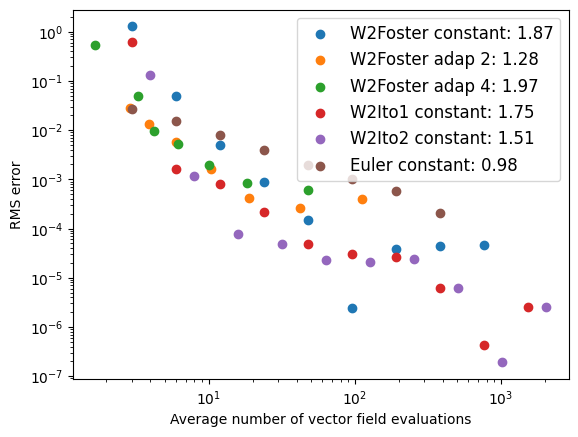

In [10]:
draw_order(results)